# Introducción a la Estadística Bayesiana

In [3]:
#| code-fold: true
import arviz as az
from ipywidgets import interact
import ipywidgets as ipyw
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
print("PreliZ:", pz.__version__)

PreliZ: 0.20.0


In [4]:
#| code-fold: true
az.style.use('arviz-doc')

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')


## **¡Un poco de contexto histórico!**

La Estadística Bayesiana recibe su nombre en honor a Thomas Bayes (1702–1761), ministro presbiteriano y matemático aficionado inglés, reconocido por haber formulado uno de los resultados más importantes de la teoría de probabilidades: *el Teorema de Bayes.*

Aunque Bayes trabajó sobre estas ideas durante su vida, sus resultados no fueron publicados por él mismo. Tras su fallecimiento, su amigo Richard Price organizó y presentó sus manuscritos ante la Royal Society de Londres. El trabajo apareció en 1763 bajo el título “An Essay towards solving a Problem in the Doctrine of Chances”.

En dicho ensayo, Bayes abordó un problema fundamental: <font color="pink"> *cómo modificar o actualizar la probabilidad de un evento cuando se dispone de nueva información. Esta idea dio origen a lo que actualmente conocemos como inferencia bayesiana, donde el conocimiento previo se combina con la evidencia observada para obtener conclusiones actualizadas.*

Décadas más tarde, Pierre-Simon Laplace (1749–1827) extendió y formalizó estas ideas, desarrollando gran parte de la base matemática de los métodos bayesianos modernos. Por este motivo, algunos autores consideran que sería más apropiado hablar de Estadística Laplaciana.

La inferencia bayesiana se basa en dos ideas fundamentales:

***Toda cantidad desconocida puede representarse mediante una distribución de probabilidad.***

***La información aportada por los datos observados permite actualizar dichas distribuciones utilizando el Teorema de Bayes.***

Dentro del enfoque bayesiano, las cantidades conocidas se consideran fijas y generalmente se denominan datos. En cambio, las cantidades desconocidas son tratadas como variables aleatorias y reciben el nombre de parámetros del modelo.

A diferencia de otros enfoques estadísticos, la Estadística Bayesiana permite incorporar información previa o conocimiento existente antes de observar los datos. Luego, a medida que se dispone de nueva evidencia, ese conocimiento inicial es actualizado de manera coherente mediante reglas probabilísticas.

Los métodos bayesianos constituyen una herramienta muy utilizada en el análisis estadístico moderno, especialmente en contextos donde existe incertidumbre, información incompleta o necesidad de realizar predicciones.

Entre las principales ventajas del enfoque bayesiano se destacan:

1. la obtención de estimaciones de parámetros con buenas propiedades estadísticas;

2. una descripción probabilística más completa de los datos observados;

3. la posibilidad de realizar predicciones y estimaciones de datos faltantes;

4. la comparación, validación y selección de modelos dentro de un mismo marco teórico;

5. y la flexibilidad computacional que ofrecen los métodos bayesianos actuales.

Veamos un poco cómo se diferencia el enfoque bayesiano del frecuentista, que es del que tenemos un poco más de conocimiento.

A modo de resumen práctico:

* El enfoque frecuentista trabaja considerando que *los parámetros son fijos* y que la variabilidad proviene de los datos.
* El enfoque bayesiano considera que *existe incertidumbre sobre los parámetros* y utiliza la teoría de probabilidades que conocemos para modelarla.

| Aspecto                           | Estadística Frecuentista                                                | Estadística Bayesiana                                                     |
| --------------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| Interpretación de la probabilidad | La probabilidad se interpreta como frecuencia relativa a largo plazo.   | La probabilidad representa un grado de creencia o incertidumbre.          |
| Parámetros del modelo             | Son valores fijos pero desconocidos.                                    | Son variables aleatorias con distribuciones de probabilidad.              |
| Datos observados                  | Son aleatorios.                                                         | Son observaciones utilizadas para actualizar información previa.          |
| Uso de información previa         | No incorpora conocimiento previo de manera formal.                      | Permite incorporar información previa mediante distribuciones *a priori*. |
| Inferencia                        | Se basa únicamente en los datos observados.                             | Combina información previa y datos observados.                            |
| Resultado típico                  | Estimaciones puntuales e intervalos de confianza.                       | Distribuciones posteriores e intervalos de credibilidad.                  |
| Actualización del conocimiento    | Generalmente no se actualiza explícitamente al incorporar nuevos datos. | El conocimiento se actualiza continuamente usando el Teorema de Bayes.    |
| Interpretación de intervalos      | Un intervalo de confianza no expresa probabilidad sobre el parámetro.   | Un intervalo de credibilidad sí puede interpretarse probabilísticamente.  |


## **La inferencia bayesiana como proceso**

Una de las características más interesantes de la Estadística Bayesiana es que, conceptualmente, su lógica resulta bastante sencilla. Toda la inferencia se construye a partir de una idea central: utilizar probabilidades para representar incertidumbre y actualizar esas probabilidades cuando se observan nuevos datos.

En este contexto, el Teorema de Bayes actúa como la herramienta fundamental que permite combinar:

* el conocimiento previo sobre un problema,
* con la evidencia aportada por los datos observados.

Siguiendo la visión propuesta por George Box y Andrew Gelman, el análisis bayesiano puede pensarse como un proceso compuesto por tres grandes etapas.


**1. Construcción de un modelo probabilístico**

El primer paso consiste en formular un modelo capaz de describir cómo se generan los datos.

Un modelo probabilístico puede entenderse como una representación matemática de un fenómeno real. En él se especifican:

* las variables observadas,
* los parámetros desconocidos,
* y las relaciones probabilísticas entre ellos.

Estas relaciones suelen expresarse mediante distribuciones de probabilidad.

En otras palabras, el modelo propone una “historia” plausible sobre el mecanismo que produjo los datos observados.

**2. Actualización del conocimiento mediante los datos**

Una vez definido el modelo y observados los datos, se utiliza el Teorema de Bayes para actualizar la información inicial sobre los parámetros desconocidos.

La información previa, representada mediante la distribución a priori, se combina con la evidencia aportada por los datos para obtener la distribución a posteriori.

Esta nueva distribución resume el conocimiento actualizado sobre el problema y constituye el elemento central de la inferencia bayesiana.

**3. Evaluación y crítica del modelo**

El último paso consiste en analizar qué tan bien el modelo representa los datos y si las conclusiones obtenidas resultan razonables.

Aunque el enfoque bayesiano posee una base teórica muy sólida, en la práctica los modelos nunca son perfectos:

* los datos pueden contener errores,
* las mediciones pueden ser incompletas,
* y los modelos suelen ser simplificaciones de fenómenos reales mucho más complejos.

Por esta razón, resulta fundamental evaluar:

* si las predicciones del modelo son coherentes con los datos observados;
* si las conclusiones obtenidas tienen sentido dentro del contexto del problema;
* y qué tan sensibles son los resultados frente a distintos supuestos del modelo.

Además, en muchos casos la inferencia bayesiana requiere métodos computacionales intensivos, por lo que frecuentemente se utilizan aproximaciones numéricas para poder trabajar con modelos complejos.

Esta forma de pensar la inferencia estadística convierte a la Estadística Bayesiana en un marco extremadamente flexible, capaz de combinar teoría probabilística, información previa y evidencia observacional dentro de un mismo esquema de análisis.

## **Introducimos el Teorema de Bayes**


El Teorema de Bayes surge directamente de una propiedad básica de las probabilidades conjuntas: *la regla de multiplicación.*

En Estadística Bayesiana utilizaremos frecuentemente:

$Y:$ para representar los datos observados.

$θ:$ para representar un parámetro desconocido del modelo.

Por ejemplo:

$Y$ podría ser un conjunto de mediciones observadas.

$θ$ podría representar la media, una probabilidad desconocida o cualquier cantidad que queramos estimar.


Regla de multiplicación:

La probabilidad conjunta entre los parámetros y los datos puede escribirse de dos maneras equivalentes:

$$p(θ,Y)=p(θ∣Y)p(Y)$$

y también:

$$p(θ,Y)=p(Y∣θ)p(θ)$$

Como ambas expresiones representan la misma probabilidad conjunta, podemos igualarlas:

$$p(θ∣Y)p(Y)=p(Y∣θ)p(θ)$$

Despejando $p(θ∣Y)$, obtenemos el Teorema de Bayes:


$$p(θ∣Y)=\frac{p(Y∣θ)p(θ)}{p(Y)}​$$


El cual podemos reescribir como sigue:

$$
\color{teal}
\overbrace{p(\theta \mid Y)}^{\text{posterior}} = \frac{\overbrace{p(Y \mid \theta)}^{\text{likelihood}} \overbrace{p(\theta)}^{\text{prior}}}{\underbrace{\int_{\Theta} p(Y \mid \theta) p(\theta) \text{d}\theta}_{\text{marginal likelihood}}}
$$



### Interpretación de los términos del Teorema de Bayes


La expresión anterior nos permite resumir la idea central de la inferencia bayesiana: actualizar nuestras creencias sobre un parámetro desconocido a partir de los datos observados.

Cada uno de sus componentes tiene un significado específico:



<font color="pink"> ***Distribución a priori o $p(θ)$***:

es la forma de introducir conocimiento previo sobre los valores que pueden tomar los parámetros.

En situaciones con escasa información previa, se suelen usar _a prioris_ que asignan igual probabilidad a todos los valores de los parámetros, otras veces se puede elegir _a prioris_ que restrinjan los valores de los parámetros a rangos razonables, algo que se conoce como regularización, por ejemplo solo valores positivos.

Muchas veces contamos con información mucho más precisa como medidas experimentales previas o límites impuesto por alguna teoría.En casos con información previa sólida, se emplean estos a prioris que reflejan explícitamente ese conocimiento.

<font color="pink"> ***likelihood  o $p(Y∣θ)$***:

es la forma de incluir nuestros datos en el análisis.

Es una expresión matemática que especifica la plausibilidad de los datos. El _likelihood_ es central tanto en estadística Bayesiana como en estadística no-Bayesiana. A medida que la cantidad de datos aumenta el _likelihood_ tiene cada vez más peso en los resultados, esto explica el porqué a veces los resultados de la estadística Bayesiana y frecuentista coinciden cuando la muestra es _grande_.

<font color="pink"> ***Distribución a posteriori o $p(θ∣Y)$***:

describe la probabilidad de los parámetros θ después de haber incorporado la información de los datos mediante _likelihood_ y un _a priori_.

Se lo suele pensar como la versión actualizada del _a priori_ tras observar los datos. ¡De hecho un _a posteriori_ puede ser un _a priori_ de un análisis a futuro!


  

<font color="pink"> ***likelihood marginal o $p(Y)$***:

también llamado evidencia, es el likelihood promediado sobre todas los posibles hipótesis (o conjunto de parámetros) $\theta$, esto es equivalente a $p(Y)$.

En general, la _evidencia_ puede ser vista como una simple constante de normalización que en la mayoría de los problemas prácticos puede (y suele) omitirse.







*Resumiendo...*

El teorema de Bayes establece la relación entre estos elementos:

$$
p(\theta \mid Y) \propto p(Y \mid \theta) p(\theta)
$$


O, en términos más simples, establece que:

$$Posterior∝Likelihood×Prior$$

¡Es decir, la distribución a posteriori de $θ$ dado los datos
$Y$ es proporcional al producto entre la verosimilitud y la distribución a priori!

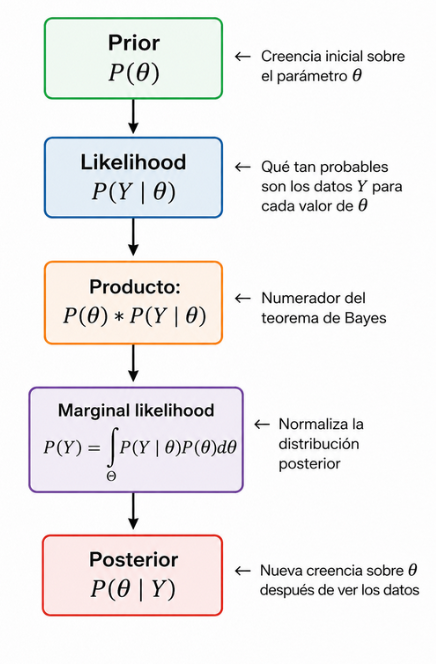

## **El a posteriori como elemento central de la inferencia bayesiana**

En Estadística Bayesiana, la distribución a posteriori ocupa un rol fundamental. Una vez observados los datos y definido el modelo probabilístico, el posterior representa todo el conocimiento actualizado que tenemos sobre los parámetros desconocidos del problema.

Recordemos que la distribución posterior se obtiene combinando:

* la información previa sobre los parámetros (prior),
* y la evidencia aportada por los datos observados (likelihood).

Por este motivo, gran parte de la inferencia bayesiana consiste en estudiar y resumir esta distribución posterior.

A partir del posterior es posible:

* estimar parámetros;
* construir intervalos de credibilidad;
* realizar predicciones;
* comparar modelos;
* y calcular cualquier cantidad de interés relacionada con el problema.

En términos generales, muchas de estas cantidades pueden escribirse como esperanzas respecto de la distribución posterior:

$$
J = \int \varphi(\theta) \ \ p(\theta \mid Y) d\theta
$$

donde:

$θ$ representa el parámetro desconocido,

$p(θ∣Y)$ es la distribución posterior,

y $φ(θ)$ es alguna función de interés sobre el parámetro.




**Ejemplo: media posterior**

Un caso particularmente importante ocurre cuando queremos calcular el valor esperado del parámetro $θ$. En ese caso, simplemente tomamos:

$$
\bar \theta = \int \theta \ \ p(\theta \mid Y) d\theta
$$

Esta expresión puede interpretarse como un promedio ponderado de todos los posibles valores del parámetro, donde cada valor recibe un peso proporcional a su probabilidad posterior.

En otras palabras: los valores de $θ$ considerados más compatibles con los datos observados tendrán mayor peso; mientras que los valores menos probables influirán menos en el resultado final.

**Aproximaciones computacionales:**

En muchos problemas reales, las integrales involucradas en inferencia bayesiana no pueden resolverse analíticamente de manera exacta.

Por esta razón, gran parte de la Estadística Bayesiana moderna utiliza métodos computacionales para aproximarlas numéricamente.

En particular, técnicas como:

$-$ simulación Monte Carlo,

$-$ métodos MCMC (Markov Chain Monte Carlo),

$-$ muestreo posterior,

que estudiaremos en los capítulos que siguen, nos permiten aproximar estas integrales mediante sumas obtenidas a partir de muestras de la distribución posterior.

Esto hace posible trabajar con modelos complejos que serían imposibles de resolver manualmente.

# **Inferencia Bayesiana para un solo parámetro:**
En la práctica la mayoría de los modelos tendrán más de un parámetro, pero empecemos con un modelo con un solo parámetro.

Las monedas constituyen uno de los ejemplos más clásicos e intuitivos dentro de la teoría de probabilidades y la inferencia estadística. Su simplicidad permite introducir conceptos complejos de manera accesible, manteniendo al mismo tiempo una formulación matemática relativamente sencilla.

Además, el experimento de lanzar una moneda no se limita únicamente a juegos de azar. Muchos problemas reales pueden modelarse utilizando exactamente la misma estructura probabilística siempre que el resultado posible tenga únicamente dos categorías mutuamente excluyentes.

Por ejemplo:

* éxito o fracaso;
* sí o no;
* aprobado o desaprobado;
* presencia o ausencia de una enfermedad;
* correo spam o no-spam;
* resultado positivo o negativo en un test diagnóstico.

En todos estos casos, cada observación puede representarse mediante una variable que solo admite dos resultados posibles.

El modelo probabilístico asociado a este tipo de situaciones se conoce como modelo binomial. Este modelo describe experimentos repetidos donde:

1. cada observación tiene únicamente dos resultados posibles;
2. las observaciones son independientes;
3. existe una probabilidad fija de obtener uno de los resultados.

En el ejemplo que analizaremos a continuación, utilizaremos lanzamientos de moneda para estudiar el concepto de <font color="orange"> *sesgo*.

###  <font color="pink"> **El problema de la moneda**

Intuitivamente, una moneda “justa” debería producir caras y cecas con igual probabilidad. Sin embargo, en la práctica, una moneda podría presentar cierta tendencia a favorecer uno de los resultados.

En este contexto, utilizaremos el término ***sesgo*** para describir cualquier desviación respecto del comportamiento perfectamente equilibrado. Más precisamente, el sesgo representará la probabilidad desconocida de obtener uno de los dos resultados posibles (por ejemplo, cara) en un lanzamiento.

Nuestro objetivo será entonces utilizar herramientas bayesianas para inferir, a partir de datos observados, qué tan probable es que la moneda se encuentre sesgada y en qué magnitud.





Diremos entonces que el ***sesgo*** de la moneda puede representarse mediante un valor perteneciente al intervalo [0,1], al que denotaremos con el parámetro $θ$.

La interpretación de $θ$ será la siguiente:

$θ=0:$ *la moneda siempre produce ceca;*

$θ=1:$ *la moneda siempre produce cara;*

$θ=0.5:$ *la moneda es perfectamente equilibrada;*

*valores intermedios indican distintos grados de preferencia hacia uno de los resultados.*

Por lo tanto, θ representa la probabilidad desconocida de obtener cara en un lanzamiento.

Nuestro objetivo será estimar este parámetro utilizando datos observados.

Para ello realizaremos una serie de lanzamientos de moneda y registraremos sus resultados. En este curso, por practicidad, simularemos los lanzamientos de manera computacional, aunque conceptualmente el procedimiento sería exactamente el mismo si realizáramos el experimento manualmente.

Denotaremos con $Y$ al conjunto de datos observados y con $y$ a la cantidad de caras obtenidas luego de realizar un cierto número de lanzamientos.

Por ejemplo, si lanzamos una moneda 10 veces y obtenemos 7 caras, entonces:

el número total de experimentos será $n=10$,
mientras que la cantidad de éxitos observados será $y=7$.

A partir de estos datos intentaremos inferir cuáles son los valores más plausibles para $θ$, es decir, qué tan sesgada parece estar la moneda según la evidencia observada.

Habiendo definido nuestro problema debemos expresarlo en términos del Teorema de Bayes,

$$
p(\theta \mid Y) \propto  p(Y \mid  \theta) p(\theta)
$$

Donde, como dijimos $\theta = 1$ quiere decir 100% cara y $\theta = 0$ 100% ceca.

<font color="pink"> Una vez que modelizamos adecuadamente, nos queda reemplazar los dos términos a la derecha de la igualdad, el *a priori* y el *likelihood*,  por distribuciones de probabilidad *adecuadas a nuestro caso de estudio* y luego multiplicarlas para obtener el término a la izquierda, el *a posteriori*:

### <font color="pink"> Primer paso: definimos el _a priori_

Para definir el *a priori* en nuestro problema clásico de la moneda, vamos a trabajar con una modelización típica dada por una distribución Beta con parámetros $\alpha$ y $\beta$.

Recordemos que la función de densidad de esta distribución es:

$$
p(\theta)= \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}\, \theta^{\alpha-1}(1-\theta)^{\beta-1}
$$

El primer término es una constante de normalización. Como nuestro problema a resolver es simple, nos alcanza con establecer una proporcionalidad y simplificar esta expresión, reescribiendo:

$$
p(\theta) \propto  \theta^{\alpha-1}(1-\theta)^{\beta-1}
$$

La distribución Beta es muy utilizada en Estadística Bayesiana porque:

1. tiene rango entre 0 y 1, de igual forma que lo hace $\theta$ en nuestro modelo.

2. esta distribución combinada con la que elegiremos como _likelihood_ (ver más adelante), nos permitirá resolver el problema de forma analítica.

3. permite abarcar distintas situaciones problemáticas.



Ejemplo concreto: supongamos que la moneda es tirada por tres personas diferentes:

 a) La primera persona dice que no tiene información sobre la moneda, por lo tanto _a priori_ todos los valores de $\theta$ son igualmente probables.

 b) La segunda persona desconfía de la moneda porque tiene la sospecha de que es una moneda que está cargada, por lo tanto considera que está sesgada aunque no sabe para cual de las dos opciones.
 c) La tercera persona asegura que lo más probable es que $\theta$ tome un valor alrededor de 0.5, pues se informó con experimentos previos similares.

 Modelizamos entonces cada caso:

C:\Users\MAURICIO\AppData\Local\Temp\ipykernel_14780\2522610981.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


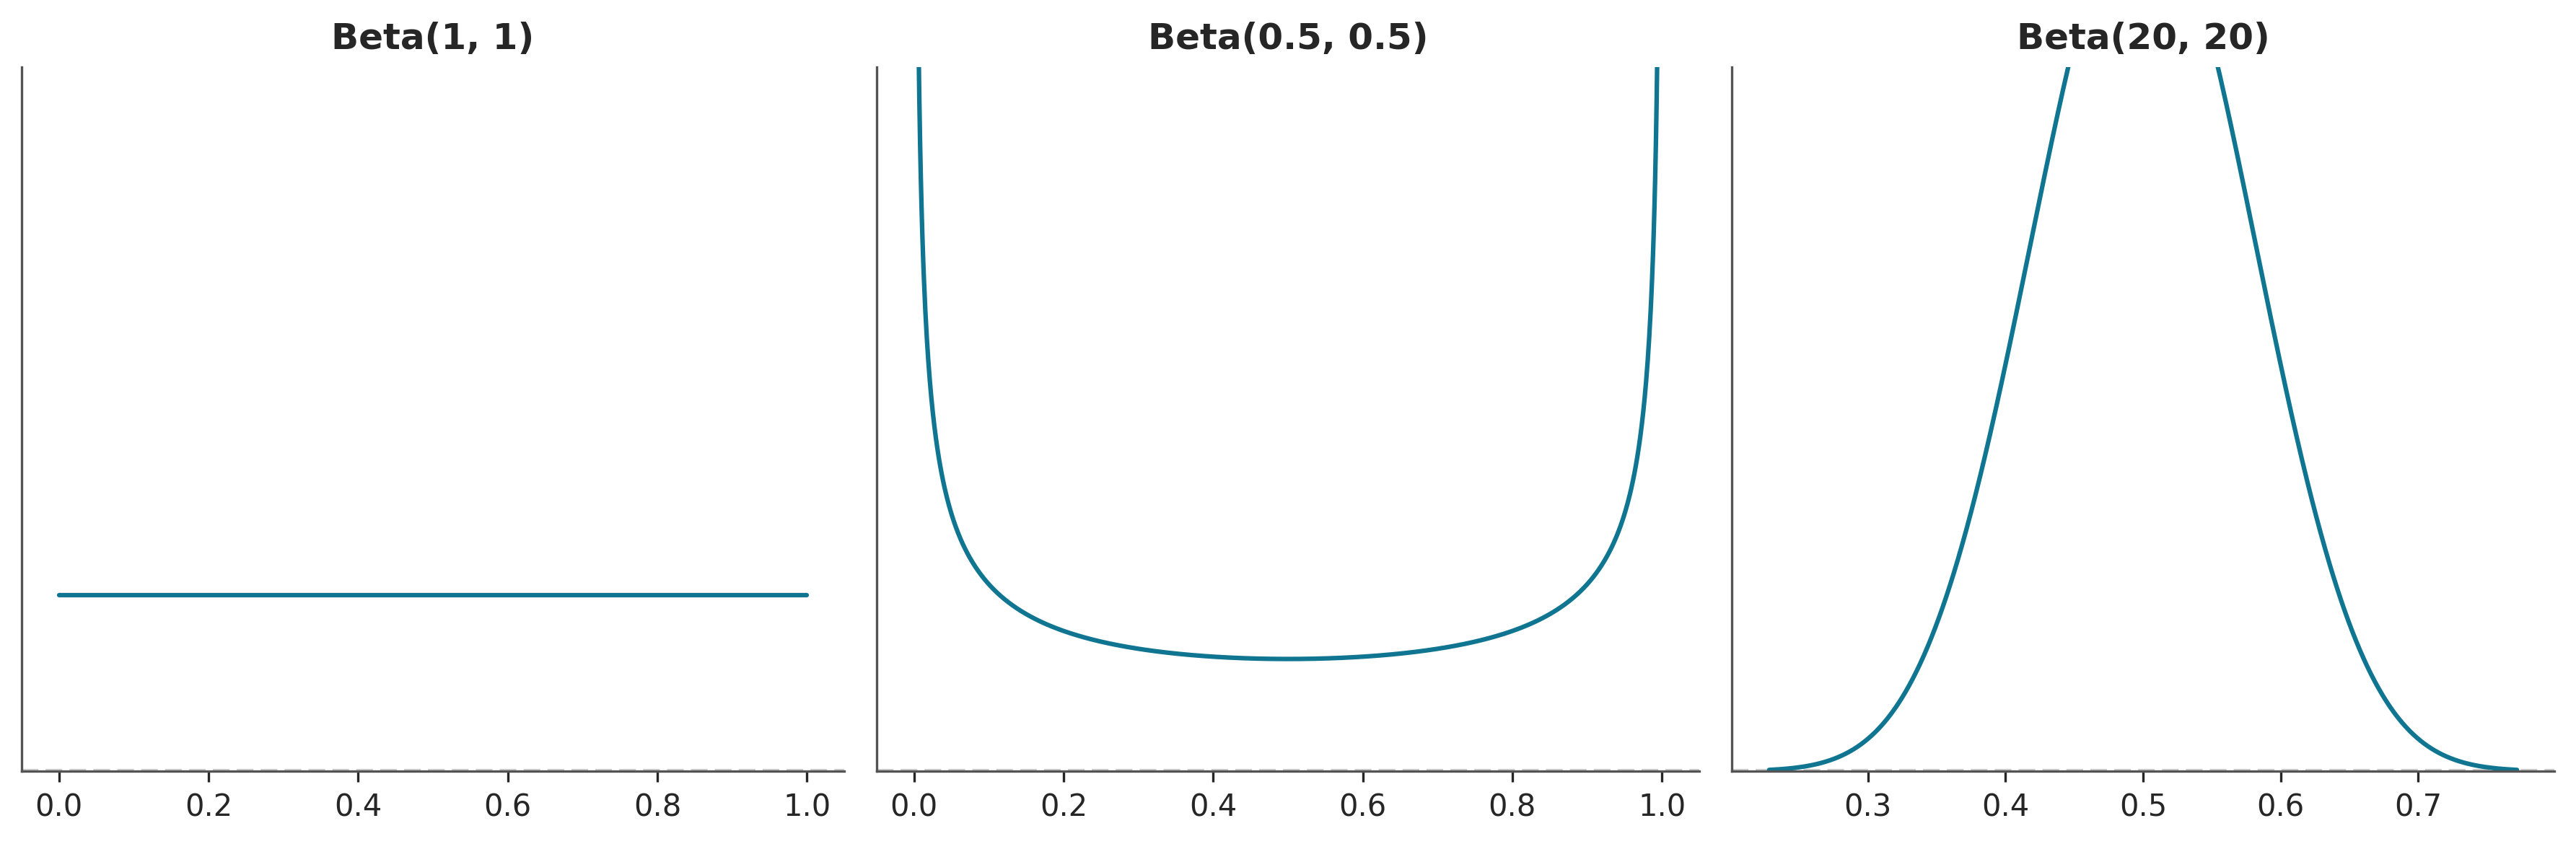

In [6]:
_, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

params = [(1, 1), (0.5, 0.5), (20, 20)]

for (a, b), ax in zip(params, axes):
    ax = pz.Beta(a, b).plot_pdf(ax=ax, legend="title")
    ax.set_ylim(0, 4)
    ax.tick_params(labelsize=10)
    ax.set_title(f"Beta({a}, {b})", fontsize=12)

plt.tight_layout()

¿Qué observamos?:

Primera imagen: distribución uniforme → ignorancia total sobre el caso

Segunda imagen: La curva en U → sospecha de sesgo.

Tercera imagen: La campana ajustada en 0.5 → confianza en una moneda justa.

**Explorando la distribución Beta:**

La distribución Beta es una de las distribuciones más utilizadas en Estadística Bayesiana para modelar probabilidades y proporciones, ya que está definida en el intervalo [0,1].

En el contexto de este curso, utilizaremos la distribución Beta para representar nuestras creencias sobre el parámetro $θ$, es decir, la probabilidad de obtener cara al lanzar una moneda.

La siguiente visualización interactiva permite modificar los parámetros de la distribución Beta y observar cómo cambia su forma.

In [ ]:
pz.Beta().plot_interactive(
    xy_lim=(None, None, None, 10),
    figsize=(3, 2)
)

interactive(children=(FloatSlider(value=2.0, description='alpha (0, inf)', max=12.0, min=2.220446049250313e-16…

Responder:

¿cómo cambian las distribuciones al modificar los parámetros α y β?

¿qué distribuciones representan mayor o menor incertidumbre?

¿cuándo la distribución favorece valores cercanos a 0, a 1 o al centro?

¿cómo se representa una creencia “neutral”?

¿cómo distribuciones más concentradas reflejan mayor confianza sobre ciertos valores del parámetro?



En particular, observen que si $α=β$, la distribución es simétrica, además de que valores grandes generan distribuciones más concentradas y valores pequeños producen distribuciones más dispersas o extremas...

###  <font color="pink"> Segundo paso: definir el _likelihood_

Habiendo definido la distribución a priori, necesitamos ahora especificar cómo modelaremos los datos observados. Para ello introducimos la verosimilitud (likelihood).

Si asumimos que cada lanzamiento de la moneda es independiente de los anteriores y que la probabilidad de obtener cara permanece constante, entonces resulta natural modelar los datos mediante una distribución binomial.

La distribución binomial describe la probabilidad de obtener una determinada cantidad de éxitos en un número fijo de experimentos independientes, siendo cada experimento de resultado binario (por ejemplo, cara o ceca).


* El modelo binomial describe la cantidad de éxitos en $N$ ensayos independientes.

* En nuestro caso: *Éxito = "el resultado de arrojar la moneda es cara"*

con Probabilidad de éxito = $θ$

* Tomamos el número de ensayos = $N$

Entonces la variable aleatoria para nuestro experimento es $Y∼Bin(N,θ)$


Exactamente: $θ$ representa la probabilidad de obtener cara en un lanzamiento, y la distribución binomial utiliza precisamente esa probabilidad como uno de sus parámetros.

En otras palabras, una vez fijado un valor de $θ$, asumimos que todos los lanzamientos tienen la misma probabilidad de éxito y que los resultados de distintos lanzamientos son independientes entre sí.

Por este motivo decimos que, *condicionado en $θ$*, los lanzamientos de moneda son independientes.

Entonces la probabilidad de observar exactamente $y$ caras en $N$ lanzamientos es

$$
p(y \mid \theta) = \frac{N!}{y!(N-y)!} \theta^y (1 - \theta)^{N−y}
$$

Donde $N$ es la cantidad total de experimentos (monedas arrojadas al aire) e $y$ es la cantidad de caras obtenidas.

La anterior expresión puede simplificarse considerablemente y convertirse en una proporcionalidad, eliminando el término $\frac{N!}{y!(N-y)!}$ ya que depende únicamente de los datos observados y no del parámetro θ, que es justamente la cantidad desconocida que queremos inferir.

Por esta razón, al trabajar en inferencia bayesiana suele reemplazarse la igualdad por una relación de proporcionalidad, conservando únicamente los términos que involucran a θ. De esta forma, podemos escribir:

$$
p(y \mid \theta) \propto \theta^y (1 - \theta)^{N−y}
$$

La elección de esta distribución para modelar nuestro problema es muy buena, dado que $\theta$ resulta ser la chance de obtener una cara al arrojar una moneda y ese hecho ha ocurrido $y$ veces, de la misma forma $1-\theta$ es la chance de obtener ceca lo cual ha sido observado $N-y$ veces.


In [ ]:
pz.Binomial(1, 0.5).plot_interactive(pointinterval=False, xy_lim=(None, None, None, 1), figsize=(3,1))

interactive(children=(IntSlider(value=1, description='n (0, inf)', max=11, style=SliderStyle(description_width…

Observemos que si consideramos una Bin(1, 0.5) → es decir el caso equilibrado.



### <font color="pink"> Tercer paso: obtener el _a posteriori_


Siempre que usemos como _prior_ una función Beta y como _likelihood_ una distribución binomial, podemos decir que obtendremos como resultado una distribución _a posteriori_  Beta (no veremos en profundidad la demostración en este curso), con los siguientes parámetros:

$$
p(\theta \mid y) = \operatorname{Beta}(\alpha_{a priori} + y, \beta_{a priori} + N - y)
$$

Veamos un poco de donde surge este resultado.

Como

$$
p(\theta \mid y) \propto p(y \mid \theta) p(\theta)
$$

tendremos que

$$
p(\theta \mid y) \propto \underbrace{{\color{gray}{\frac{N!}{y!(N-y)!}}} \theta^y (1 - \theta)^{N−y}}_{\text{likelihood}} \underbrace{{\color{gray}{\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}}}\, \theta^{\alpha-1}(1-\theta)^{\beta-1}}_{\text{prior}}
$$

Omitiendo las constantes de normalizando del likelihood y prior, el _a posteriori_ resultante es:

$$
p(\theta \mid y) \propto \theta^{\alpha-1+y}(1-\theta)^{\beta-1+N−y}
$$

Podemos ver que la expresión a la derecha de la proporcionalidad tiene la misma forma funcional (sin considerar la constante de proporcionalidad) que una distribución Beta. Como la distribución a posterior debe intergrar a 1 entonces podemos escribir:

$$
p(\theta \mid y) = \frac{\Gamma(\alpha + y +\beta + N -y)}{\Gamma(\alpha + y)\Gamma(\beta + N - y)}\, \theta^{\alpha-1+y}(1-\theta)^{\beta-1+n-y}
$$

Lo que es equivalente a una distribución Beta con parámetros $\alpha_{\text{a posteriori}} = \alpha_{\text{a priori}} + y \quad \beta_{\text{a posteriori}} = \beta_{\text{a priori}} + N - y$.



Se dice que *una distribución a priori es conjugada respecto de un determinado likelihood cuando la distribución a posteriori pertenece a la misma familia probabilística que el prior*.

Es decir, luego de aplicar el Teorema de Bayes, la forma funcional de la distribución se conserva, modificándose únicamente sus parámetros.

Por ejemplo:

* un prior Beta combinado con un likelihood Binomial produce un posterior Beta;
* un prior Gamma combinado con un likelihood Poisson produce un posterior Gamma.

Históricamente, los modelos conjugados tuvieron un papel central en el desarrollo de la Estadística Bayesiana, especialmente en épocas donde los recursos computacionales eran limitados.

La principal ventaja de utilizar prioris conjugados es que permiten obtener expresiones analíticas exactas para la distribución posterior, evitando cálculos complejos o aproximaciones numéricas.

En otras palabras, la conjugación aporta una gran simplicidad matemática, ya que facilita:

* el cálculo del posterior;
* la obtención de estimadores;
* y la interpretación de los resultados.

Actualmente, gracias al desarrollo de métodos computacionales modernos, es posible trabajar también con modelos no conjugados mucho más flexibles. Sin embargo, los modelos conjugados continúan siendo extremadamente importantes desde el punto de vista pedagógico e intuitivo, además de seguir siendo útiles en numerosos problemas prácticos.

#  **¿Cómo representamos los modelos Bayesianos?**

Para describir de manera compacta un modelo bayesiano suele utilizarse una notación probabilística basada en distribuciones. Esta forma de escribir modelos resulta muy útil porque permite expresar claramente:

cuáles son los parámetros desconocidos;
qué distribuciones se les asignan;
y cómo se generan los datos observados.

En nuestro caso, el modelo puede resumirse mediante:

\begin{align}\theta &\sim \operatorname{Beta}(\alpha,\beta)\\Y &\sim \operatorname{Bin}(n=1,p=\theta)\end{align}

La primera línea indica que el parámetro desconocido θ, es decir, la probabilidad de obtener cara, se modela mediante una distribución Beta con parámetros α y β.

En el enfoque bayesiano, esto representa nuestra incertidumbre inicial sobre el verdadero valor del parámetro antes de observar datos.

La segunda línea establece que los datos observados Y siguen una distribución binomial con probabilidad de éxito θ. En este contexto, cada lanzamiento puede tomar únicamente dos resultados posibles:

cara (éxito),

o ceca (fracaso).

Cuando n=1, la distribución binomial coincide con una distribución Bernoulli, es decir, modela un único experimento binario.

Esta notación resume completamente el modelo probabilístico:

el prior describe nuestras creencias iniciales;

mientras que el likelihood describe cómo se generan los datos a partir del parámetro desconocido.



---------------------------------------------------------------------------------------------------

# Analicemos un ejemplo con observaciones conocidas
¿Cómo podemos conseguir los datos para nuestra aplicación del modelo anterior?:

Trabajaremos con un ejemplo con datos sintéticos, obtienidos mediante un generador de números (pseudo)aleatorios.

**Ustedes pueden obtener datos reales arrojando una moneda y anotando los resultados observados, como les dejé de tarea** 😃

### Cálculo del _a posteriori_

Trabajemos con la expresión del _a posteriori_ desde el punto de vista computacional:



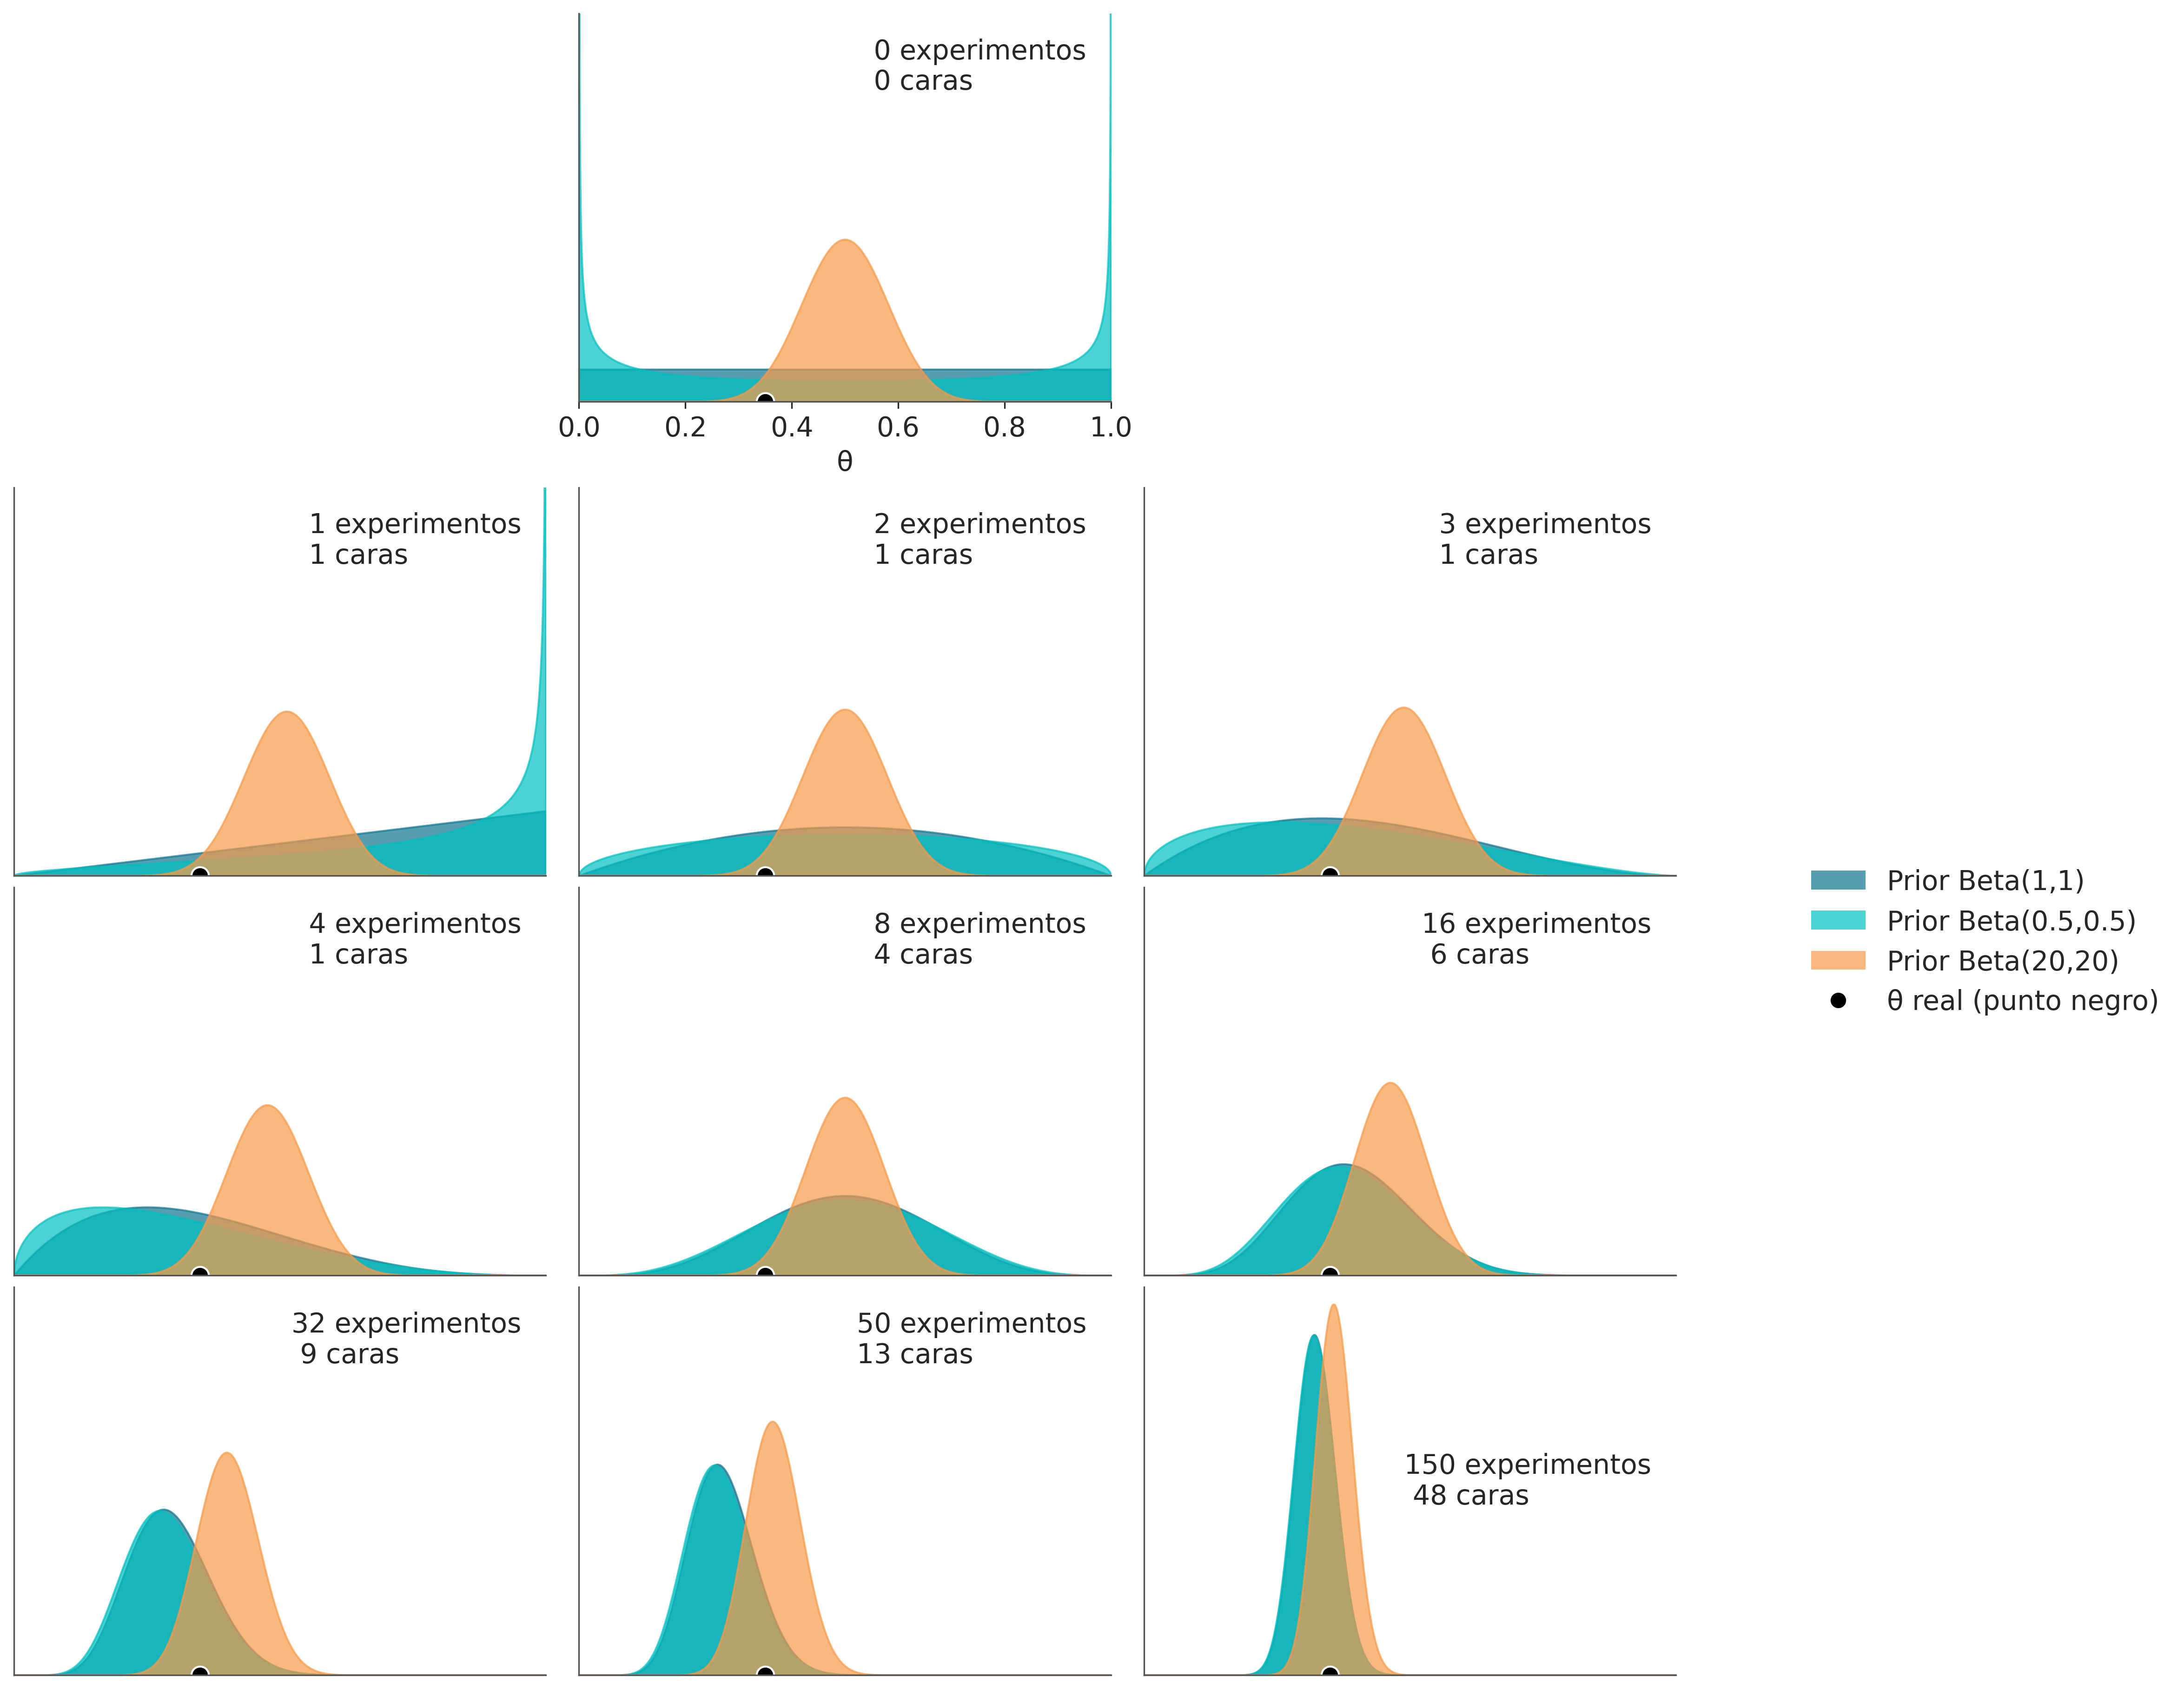

In [15]:
plt.figure(figsize=(12, 12))

n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
data = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
theta_real = 0.35

beta_params = [(1, 1), (0.5, 0.5), (20, 20)]
dist = pz.Beta
x = np.linspace(0, 1, 2000)

for idx, N in enumerate(n_trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
        plt.xlabel('θ')
    else:
        plt.subplot(4, 3, idx+3)
        plt.xticks([])
    y = data[idx]
    for i, (a_prior, b_prior) in enumerate(beta_params):
        posterior = dist(a_prior + y, b_prior + N - y).pdf(x)
        plt.fill_between(x, 0, posterior, alpha=0.7, color=f'C{i}')

    plt.plot(theta_real, 0, ms=9, marker='o', mec='w', mfc='k')
    plt.plot(0, 0, label=f'{N:4d} experimentos\n{y:4d} caras', alpha=0)
    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.yticks([])
    plt.legend()  # mantiene las etiquetas invisibles para cada subplot

# Leyenda
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='C0', alpha=0.7, label='Prior Beta(1,1)'),
    Patch(facecolor='C1', alpha=0.7, label='Prior Beta(0.5,0.5)'),
    Patch(facecolor='C2', alpha=0.7, label='Prior Beta(20,20)'),
    Line2D([0], [0], marker='o', color='w', label='θ real (punto negro)', markerfacecolor='k', markersize=9)
]

plt.gcf().legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 0.5))

plt.show()

Observaciones:

Al analizar el código es importante notar que gran parte de las líneas están dedicadas a la visualización de resultados y no al cálculo estadístico en sí mismo.

De hecho, el cálculo del a posteriori ocurre únicamente en una línea específica del programa. Allí se evalúa la distribución posterior utilizando la función pdf de la distribución Beta provista por la librería *PreliZ*.

El procedimiento es relativamente sencillo:

se generan 2000 valores igualmente espaciados entre 0 y 1 y luego se calcula la densidad posterior para cada uno de esos puntos.

Esto permite obtener una representación suave de la distribución posterior y visualizar cómo cambian nuestras creencias sobre el parámetro $θ$.

Además, el ciclo for presente en el código tiene como objetivo estudiar cómo evoluciona la distribución posterior a medida que aumenta la cantidad de datos observados (n_intentos).

De esta forma puede verse claramente una de las ideas centrales de la inferencia bayesiana:

1. con pocos datos, el prior tiene una influencia importante;
2. mientras que, al aumentar la evidencia observacional, el posterior comienza  a concentrarse alrededor de los valores más compatibles con los datos.

Finalmente, en los gráficos se marca con un círculo negro el valor verdadero de $θ$. En un problema real este valor sería desconocido, pero en este caso resulta útil porque los datos fueron generados artificialmente y conocemos exactamente el parámetro utilizado para simularlos. Esto permite comparar visualmente qué tan bien el modelo logra recuperar el valor real a partir de los datos observados.

## Analizando los resultados ¿ Qué nos muestran estos gráficos?



**Interpretación de los resultados:**

La primera figura muestra las distribuciones a priori, es decir, nuestras creencias sobre el valor de θ antes de observar datos.

Las figuras restantes muestran cómo estas distribuciones se actualizan al incorporar resultados de lanzamientos de moneda. En cada gráfico se indica:

la cantidad de experimentos realizados;
y la cantidad de caras observadas.

Además, el punto negro marca el valor verdadero de $θ=0.35$, conocido únicamente porque los datos fueron simulados.

Este ejemplo permite observar varias ideas importantes de la inferencia bayesiana:

El resultado de un análisis bayesiano no es un único número, sino una distribución completa de valores plausibles para el parámetro.

El ancho de la distribución refleja el nivel de incertidumbre:

distribuciones anchas indican mayor incertidumbre;

distribuciones más concentradas indican mayor confianza sobre ciertos valores.

El valor más probable corresponde al pico de la distribución posterior.

A medida que aumenta la cantidad de datos observados, la incertidumbre disminuye y las distribuciones se vuelven más concentradas.

Aunque distintos prioris produzcan resultados diferentes al comienzo, con suficientes datos las distribuciones posteriores tienden a parecerse.

Los prioris más informativos (más concentrados) necesitan una mayor cantidad de datos para ser modificados significativamente.

Con muy pocos datos, el prior puede influir fuertemente en las conclusiones obtenidas.

En cambio, cuando la cantidad de observaciones crece, los datos dominan progresivamente la inferencia.

Finalmente, puede observarse que el prior uniforme representa una postura relativamente “neutral”, ya que inicialmente asigna probabilidades similares a todos los valores posibles de $θ$.

**¿Cuántos datos hacen falta?**

No existe una respuesta universal. La rapidez con la que “desaparece” la influencia del prior depende tanto del problema como del tipo de prior utilizado.

En el ejemplo de la moneda vimos que:

algunos prioris producen resultados muy similares luego de pocas observaciones;
mientras que prioris más concentrados requieren una mayor cantidad de datos para ser modificados significativamente.

Esto ocurre porque un prior muy concentrado representa una creencia previa fuerte. Por ejemplo, un prior como:

$Beta(20,20)$

asigna gran parte de la probabilidad a valores cercanos a 0.5, indicando una fuerte creencia inicial en que la moneda es aproximadamente equilibrada.

En cambio, un prior como:

$Beta(2,2)$

también favorece valores cercanos a 0.5, pero de manera mucho más flexible y menos restrictiva.

**¿Los prioris “contaminan” el análisis?**

La elección del prior suele generar dudas en quienes se acercan por primera vez a la Estadística Bayesiana. Una preocupación frecuente es pensar que el prior podría “forzar” los resultados o impedir que los datos “hablen por sí mismos”.

Sin embargo, los datos nunca se interpretan de manera aislada. Todo análisis estadístico necesita supuestos y modelos para poder extraer conclusiones.

En el enfoque bayesiano, los prioris forman parte explícita de esos supuestos.

Lejos de ser un problema, esto aporta transparencia:

* las hipótesis quedan visibles;
* pueden discutirse;
* y también pueden modificarse o compararse.

**Prioris no informativos e informativos**

En términos generales, los prioris suelen clasificarse según la cantidad de información previa que incorporan.

***Prioris no informativos***

También llamados *planos, vagos, o difusos*.

Buscan introducir la menor cantidad posible de información previa, permitiendo que los datos dominen rápidamente la inferencia.

En muchos casos, utilizar prioris poco informativos conduce a resultados similares a los obtenidos mediante métodos frecuentistas.

Por ejemplo, en el caso binomial, la estimación frecuentista clásica para $θ$ es:

$$\hat{θ}=\frac{y}{N}$$
	​


A diferencia del enfoque bayesiano, esta estimación corresponde únicamente a un valor puntual y no a una distribución completa de incertidumbre.

**Prioris ligeramente informativos**

En la práctica, muchas veces sí disponemos de cierta información previa razonable:

sabemos que un parámetro debe ser positivo;

que una probabilidad debe estar entre 0 y 1;

o que ciertos valores extremos son poco plausibles.

En estos casos resulta útil utilizar prioris ligeramente informativos, que ayudan a mantener las inferencias dentro de rangos razonables sin imponer restricciones demasiado fuertes.

Este tipo de prioris suele actuar como un mecanismo de regularización.

**Prioris informativos**

Cuando existe información previa confiable, también es posible utilizar prioris fuertemente informativos.

Esto puede ser especialmente útil cuando:

los datos disponibles son escasos;

o el problema contiene mucho ruido e incertidumbre.

En disciplinas como bioinformática, medicina o física experimental, es común aprovechar información acumulada durante años de investigaciones previas. Ignorar ese conocimiento muchas veces sería poco razonable.

**No existen modelos “sin prior”**

Desde una perspectiva bayesiana, todo modelo incorpora supuestos previos, incluso cuando estos no aparecen escritos explícitamente.

De hecho, muchos procedimientos frecuentistas pueden interpretarse como casos particulares de modelos bayesianos con prioris planos o débiles.

Por este motivo, especificar los prioris de manera explícita suele ser más transparente que asumirlos implícitamente.

Además, hacerlo permite:

controlar mejor el modelo;

estudiar cómo afectan los supuestos a las conclusiones;

y cuantificar adecuadamente la incertidumbre.

**Sensibilidad y comparación de modelos**

El modelado estadístico es un proceso iterativo. Nada obliga a utilizar un único prior.

En muchos problemas resulta útil comparar distintos prioris razonables y analizar cómo cambian los resultados. Esto se conoce como análisis de sensibilidad.

Si las conclusiones permanecen estables frente a distintos prioris, entonces podemos tener mayor confianza en la robustez del análisis.

Más adelante veremos herramientas que permiten comparar modelos y evaluar formalmente diferentes elecciones de prioris y likelihoods.

Con los ejemplos anteriores podemos concluir que la elección del a priori influye sobre los resultados obtenidos, pues si el prior no tuviera ningún efecto, entonces no tendría sentido incluirlo en el análisis bayesiano.

Además, a medida que aumenta la cantidad de datos disponibles, la influencia del prior disminuye progresivamente. Esto significa que cuando la evidencia observacional es abundante, el posterior queda dominado principalmente por los datos.
Incluso se puede observar que bajo ciertas condiciones, con una cantidad suficientemente grande de observaciones, los distintos prioris tienden a conducir a conclusiones similares.

## **Cuantificando el peso del _a priori_**

Si queremos expresar la distribución Beta en función de la media y el desvío, podemos realizar las siguientes conversioens:

\begin{align}
\alpha &= \mu \kappa \\
\beta &= (1 - \mu) \kappa
\end{align}

donde $\mu$ es la media y $\kappa$ es un parámetro llamado concentración. Por ejemplo si $\mu=0.5$ y $\kappa=40$, tenemos que:

\begin{align}
\alpha = 0.5 \times 40 &= 20 \\
\beta = (1-0.5) \times 40 &= 20
\end{align}

donde $\kappa$ sería la cantidad de experimentos "si/no" que realizamos dándonos como resultado la media $\mu$.

* Es decir el _a priori_ no sesgado (naranja) equivale a haber arrojado una moneda 40 veces y haber obtenido como media 0.5. Es decir que si usamos ese _a priori_ recién al observar 40 experimentos si/no, los datos tendrán el mismo peso relativo que el _a priori_, por debajo de este número el _a priori_ contribuye más que los datos al resultado final y por encima menos.

Observemos:

* El _a priori_ azul (uniforme) equivale a haber observado a la moneda caer una vez cara y otra vez ceca ($\kappa = 2$).

* Cuando $\kappa < 2$, la cosa se pone un poco extraña, por ejemplo el _a priori_ sesgado (turquesa) equivale a haber observado una sola moneda ($\kappa = 1$) pero en una especie de, a falta de mejor analogía, ¡¿_superposición cuántica de estados_?!

### Resumiendo el  _a posteriori_

El resultado de un análisis Bayesiano es siempre una distribución de probabilidad.

A la hora de comunicar los resultados de un análisis Bayesiano, lo más informativo es reportar la distribución completa, aunque esto no siempre es posible o deseable, por ejemplo el _a posteriori_ de una distribución multidimensional es imposible de visualizar de forma directa. Por lo tanto, es común recurrir a distintas medidas que resumen el _a posteriori_, por ejemplo la media, mediana, la desviación estándar, etc. También es común, e informativo, reportar un intervalo de credibilidad. Existen varios criterios para definir intervalos de credibilidad, el que usaremos en este curso (y que también es ampliamente usado en la literatura) es lo que se conoce como intervalo de más alta densidad y nos referiremos a él por su sigla en ingles, HDI (_Highest Posterior Density interval_). Un HDI es el intervalo, más corto, que contiene una porción fija de la densidad de probabilidad, generalmente el 95% (aunque otros valores como 90% o 50% son comunes). Cualquier punto dentro de este intervalo tiene mayor densidad que cualquier punto fuera del intervalo. Para una distribución unimodal, el HDI 95 es simplemente el intervalo entre los percentiles 2,5 y 97,5.


Profundizaremos en el siguiente capítulo cómo dar tratamiento computacional a problemas bayesianos simple con funcionalidades de Python, en particular, *ArviZ* es un paquete de Python para análisis exploratorio de modelos Bayesianos que nos permite obtener funciones para analizar y resumir el _a posteriori_.

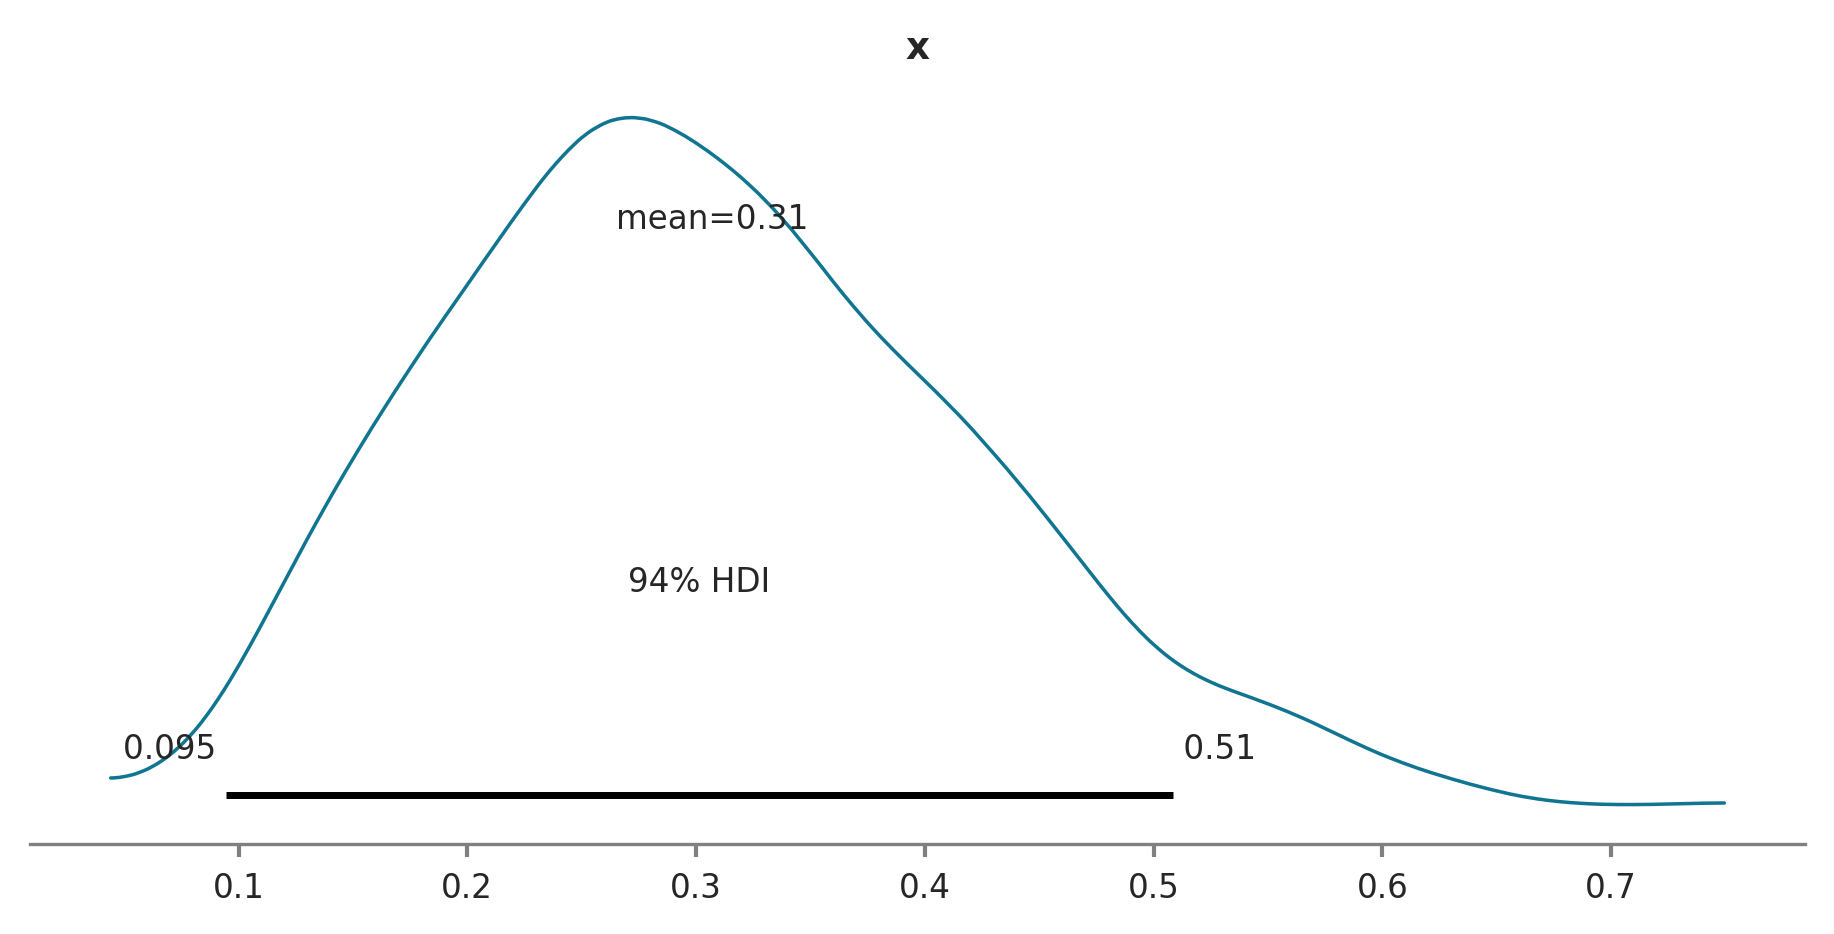

In [10]:
mock_posterior = pz.Beta(5, 11).rvs(size=1000)
az.plot_posterior(mock_posterior, figsize=(6, 3));

In [11]:
#!pip uninstall -y pymc
#!pip install --upgrade --force-reinstall preliz pytensor numba llvmlite
#!pip install pymc>=6.0.0  # Install a PyMC version compatible with PyTensor 3.x

In [12]:
#mock_posterior = pz.Beta(5, 11).rvs(size=1000)
#az.plot_posterior(mock_posterior, figsize=(6, 3));

## **Construyendo un HDI** (retomaremos en los siguientes capítulos)

En el gráfico anterior utilizamos la función `plot_posterior`  para generar un gráfico con la media y el HDI. En el siguiente ejemplo en vez de un _a posteriori_ "real" estamos usando datos sintéticos generados de una distribución Beta.

**Intervalos HDI**

Una forma muy común de resumir una distribución a posteriori consiste en construir intervalos que contengan los valores más plausibles del parámetro.

En Estadística Bayesiana, uno de los intervalos más utilizados es el HDI (Highest Density Interval), o intervalo de mayor densidad.

Un HDI contiene la región de la distribución posterior donde se concentran los valores más probables del parámetro.

Por ejemplo, un HDI del 95% representa un intervalo que contiene el 95% de la probabilidad posterior, seleccionando siempre las zonas de mayor densidad.

Una propiedad importante del HDI es que:

cualquier punto dentro del intervalo tiene mayor densidad posterior que cualquier punto fuera de él.

Esto lo diferencia de otros intervalos construidos únicamente a partir de percentiles.


Si obtenemos, por ejemplo, un HDI del 95% para un parámetro $θ$:

$$[0.32, 0.51]$$

***Enfoque bayesiano:***

dado el modelo y los datos observados, los valores más plausibles para θ se encuentran dentro de ese intervalo.

Además, dentro del marco bayesiano podemos afirmar que existe un 95% de probabilidad posterior de que el parámetro pertenezca a dicho rango.

Algunas observaciones importantes

Ahora que estamos introduciendo el concepto de HDI por primera vez, conviene aclarar algunos puntos importantes antes de automatizar su uso.

Elección del porcentaje del HDI

La elección de un HDI del 95% (o cualquier otro valor) es esencialmente arbitraria.

No existe ninguna razón matemática fundamental para preferir:

95%,

90%,

94%,

o incluso valores menos convencionales como 66% u 87%.

El uso de 95% responde principalmente a una convención histórica heredada de la estadística clásica. Como recordatorio de esta arbitrariedad, la librería ArviZ utiliza por defecto un HDI del 94%.

**HDI vs intervalo de confianza**

Un intervalo de credibilidad bayesiano *no es lo mismo* que un intervalo de confianza frecuentista, aunque muchas veces ambos se confunden.

Intervalo de credibilidad (Bayesiano)

En el enfoque bayesiano, podemos decir:

existe una probabilidad del 95% de que el parámetro pertenezca al intervalo.

Esto es posible porque el parámetro se modela mediante una distribución de probabilidad.

Intervalo de confianza (Frecuentista)

En estadística frecuentista, el parámetro se considera fijo y desconocido.

Un intervalo de confianza del 95% significa que:

si repitiésemos el experimento infinitas veces y construyésemos un intervalo en cada repetición, entonces aproximadamente el 95% de esos intervalos contendrían el verdadero valor del parámetro.

Esto NO significa que un intervalo particular tenga 95% de probabilidad de contener el parámetro.

Aunque esta diferencia es conceptualmente importante, en la práctica suele resultar bastante contraintuitiva y frecuentemente genera confusión.


Es importante recordar que toda inferencia bayesiana depende de los datos observados y los supuestos del modelo utilizado.

Por lo tanto, cuando afirmamos que existe cierta probabilidad de que un parámetro pertenezca a un intervalo, esa afirmación es válida únicamente dentro del marco del modelo asumido.

Si el modelo es incorrecto o los datos contienen problemas importantes, las conclusiones también pueden verse afectadas.

## Distribución predictivas



### Distribución predictivas  _a posteriori_


Esta distribución representa las predicciones $\tilde{y}$ de un modelo una vez obtenido el _a posteriori_:

$$
p(\tilde{y}  \mid  y) = \int p(\tilde{y} \mid \theta) p(\theta \mid y) d\theta
$$

Observar que la integral se hace sobre $\theta$ según la distribución _a posteriori_.

Modelo computacional:

1. Elegir  $\theta$ de acuerdo a la distribución a posteriori $p(\theta \mid y)$

2. Fijar $\theta$ en la distribución que usamos como likelihood $p(\tilde{y} \mid \theta)$ y generamos una muestra aleatoria

3. Repetir desde 1 las veces que sean necesarias.



### Distribución predictiva _a priori_

Asi como es posible generar datos sintéticos desde el _a posteriori_, podemos realizar un procedimiento similar desde el prior, obteniendo la distribución predictiva _a priori_. Esta representa los datos $p(y^\ast)$ que el modelo *espera* ver antes de haber visto los datos:

$$
p(y^\ast) =  \int p(y^\ast \mid \theta) \; p(\theta) \; d\theta
$$


### Distribución predictiva _a priori_ y a posterior para el problema de la moneda.

En el caso del modelo beta-binomial es posible obtener analíticamente tanto la distribución predictiva a priori como a posteriori y estas son:

$$
p(y^\ast) \propto \operatorname{Beta-binomial}(n=N, \alpha_{a priori}, \beta_{a priori})
$$


$$
p(\tilde{y}  \mid  y)  \propto \operatorname{Beta-binomial}(n=N, \alpha_{a priori} + y, \beta_{a priori} + N - y)
$$

Omitiremos la discusión de como se obtienen estas distribuciones

## Resumamos los cuatro elementos principales del mundo bayesiano:

En el siguiente bloque de código se calcularán y visualizarán cuatro distribuciones fundamentales dentro del enfoque bayesiano, según lo estudiado hasta ahora:

**distribución a priori;**

**distribución a posteriori;**

**distribución predictiva a priori;**

**distribución predictiva a posteriori.**

Estas cuatro distribuciones suelen conocerse informalmente como *el cuarteto bayesiano*, ya que resumen los principales componentes de un análisis bayesiano completo.

**¿Qué representa cada distribución?**

La distribución a priori describe nuestras creencias sobre el parámetro antes de observar datos.

La distribución a posteriori representa el conocimiento actualizado luego de incorporar la evidencia observacional.

La distribución predictiva a priori modela posibles datos futuros usando únicamente la información previa.

La distribución predictiva a posteriori modela datos futuros utilizando tanto el prior como los datos ya observados.

Distribuciones sobre parámetros vs distribuciones sobre datos

Es importante distinguir entre dos tipos de distribuciones:

**Distribuciones sobre parámetros:**

*Las distribuciones a priori y a posteriori*

están definidas sobre los parámetros del modelo, en este caso sobre $θ$.

Estas distribuciones representan incertidumbre acerca del valor desconocido del parámetro.

**Distribuciones predictivas:**

*Las distribuciones predictiva a priori y predictiva a posteriori*

no describen parámetros, sino posibles valores futuros de los datos observados.

Es decir, representan qué resultados esperaríamos observar bajo el modelo probabilístico.



### **Implementación computacional:**

Para calcular las distribuciones predictivas podría utilizarse directamente la distribución Beta-Binomial. Sin embargo, en este ejemplo utilizaremos un enfoque más computacional e intuitivo.

El procedimiento consiste en:

muestrear valores de $θ$ desde una distribución Beta;
y luego generar observaciones binomiales condicionadas a esos valores.

Aunque este método puede resultar menos compacto desde el punto de vista matemático, permite visualizar de manera más clara cómo se generan las predicciones en un modelo bayesiano y ayuda a construir intuición sobre el significado de las distribuciones predictivas.

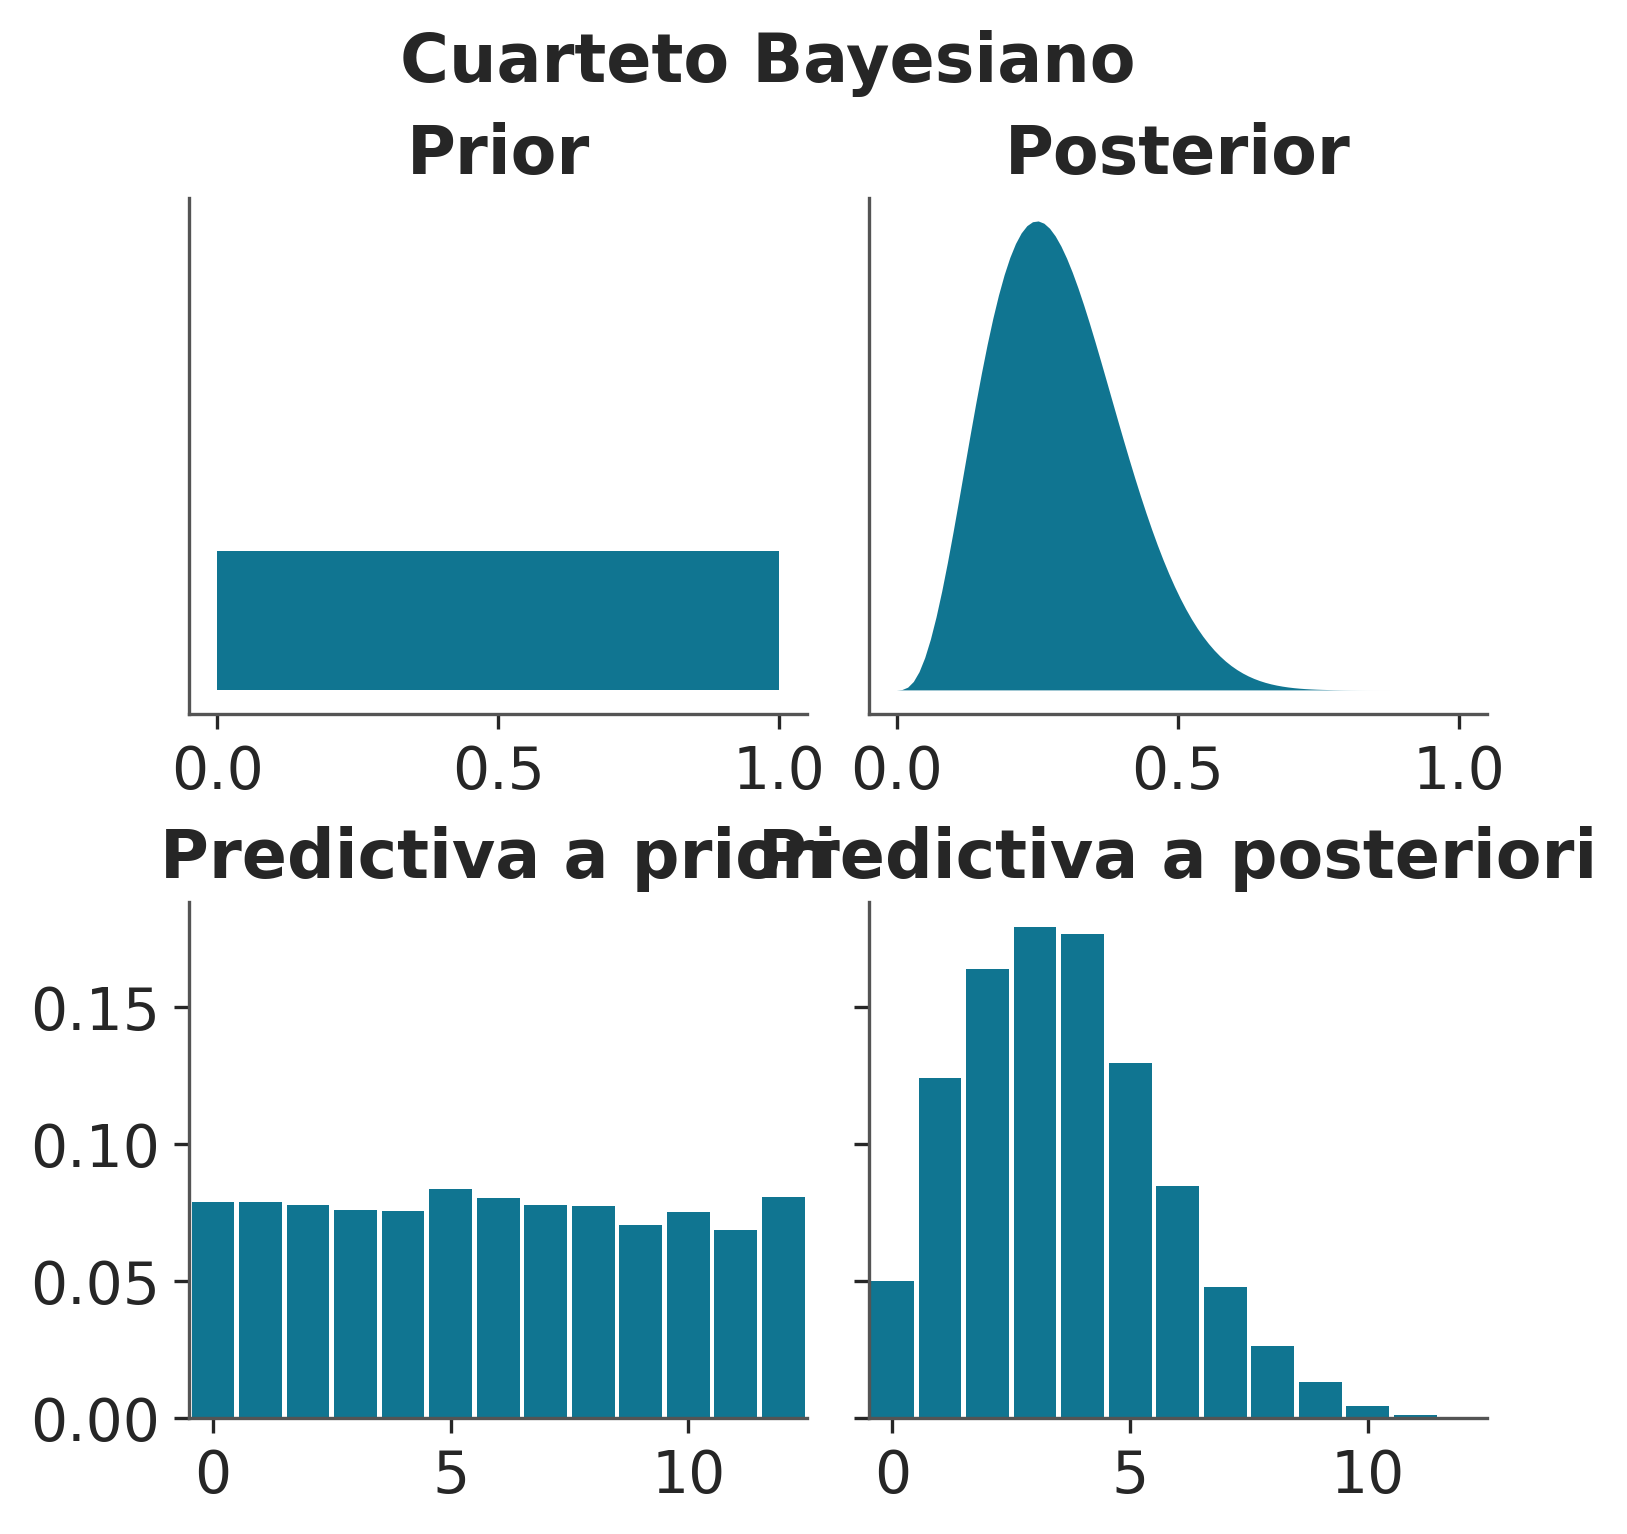

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5), sharex="row", sharey="row")
axes = np.ravel(axes)
dist = pz.Beta
a_prior = 1
b_prior = 1
N = 12
y = 3
eps = np.finfo(float).eps
x = np.linspace(eps, 1-eps, 100)


prior = dist(a_prior, b_prior).pdf(x)
axes[0].fill_between(x, 0, prior)
axes[0].set_title("Prior")
axes[0].set_yticks([])


posterior = dist(a_prior + y, b_prior + N - y).pdf(x)
axes[1].fill_between(x, 0, posterior)
axes[1].set_title("Posterior")


prior = dist(a_prior, b_prior).rvs(500)
prior_predictive = np.hstack([pz.Binomial(n=N, p=p).rvs(N) for p in prior])
axes[2].hist(prior_predictive, bins=range(0, N+2), rwidth=0.9, align="left", density=True)
axes[2].set_xlim(-0.5, N+0.5)
axes[2].set_title("Predictiva a priori")

posterior = dist(a_prior + y, b_prior + N - y).rvs(500)
prior_predictive = np.hstack([pz.Binomial(n=N, p=p).rvs(N) for p in posterior])
axes[3].hist(prior_predictive, bins=range(0, N+2), rwidth=0.9, align="left", density=True)
axes[3].set_xlim(-0.5, N+0.5)
axes[3].set_title("Predictiva a posteriori");

fig.suptitle("Cuarteto Bayesiano", fontweight="bold", fontsize=16);